In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder

In [9]:
# import data
banking_marketing_train_original = pd.read_csv('banking_marketing_train.csv', delimiter=';', quotechar='"')
banking_marketing_test_original = pd.read_csv('banking_marketing_test.csv', delimiter=';', quotechar='"')
banking_marketing_train_original.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [10]:
# import data
banking_marketing_train = pd.read_csv('banking_marketing_train.csv', delimiter=';', quotechar='"')
banking_marketing_test = pd.read_csv('banking_marketing_test.csv', delimiter=';', quotechar='"')
banking_marketing_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# Data Cleaning

In [11]:
banking_marketing_train.info()
banking_marketing_train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [12]:
# check for missing values
banking_marketing_train.isna().sum()

# no na

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [13]:
# check for duplicate rows
banking_marketing_train.duplicated().sum()

# no duplicate rows

np.int64(0)

In [14]:
banking_marketing_train.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [15]:
# convert columns with number to numeric
numeric_columns = ['age','balance','day','duration','campaign','pdays','previous']
for col in numeric_columns:
    print(f"Category counts for column '{col}':")
    print(banking_marketing_train[col].value_counts())
    print("\n")

Category counts for column 'age':
age
32    2085
31    1996
33    1972
34    1930
35    1894
      ... 
95       2
93       2
92       2
88       2
94       1
Name: count, Length: 77, dtype: int64


Category counts for column 'balance':
balance
0        3514
1         195
2         156
4         139
3         134
         ... 
14204       1
8205        1
9710        1
7038        1
4416        1
Name: count, Length: 7168, dtype: int64


Category counts for column 'day':
day
20    2752
18    2308
21    2026
17    1939
6     1932
5     1910
14    1848
8     1842
28    1830
7     1817
19    1757
29    1745
15    1703
12    1603
13    1585
30    1566
9     1561
11    1479
4     1445
16    1415
2     1293
27    1121
3     1079
26    1035
23     939
22     905
25     840
31     643
10     524
24     447
1      322
Name: count, dtype: int64


Category counts for column 'duration':
duration
124     188
90      184
89      177
104     175
114     175
       ... 
1286      1
1380      1
1723    

In [16]:
banking_marketing_train.select_dtypes(include=['number'])

,age,balance,day,duration,campaign,pdays,previous
0,58,2143,5,261,1,-1,0
1,44,29,5,151,1,-1,0
2,33,2,5,76,1,-1,0
3,47,1506,5,92,1,-1,0
4,33,1,5,198,1,-1,0
...,...,...,...,...,...,...,...
45206,51,825,17,977,3,-1,0
45207,71,1729,17,456,2,-1,0
45208,72,5715,17,1127,5,184,3
45209,57,668,17,508,4,-1,0


In [17]:
banking_marketing_train.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


# Encoding

In [18]:
banking_marketing_train_encoded = banking_marketing_train
banking_marketing_test_encoded = banking_marketing_test

## Binary Encoding (yes/no)

In [19]:
binary_columns = ['default','housing','loan','y']
binary_columns = [col for col in binary_columns if col in banking_marketing_train.columns]
for col in binary_columns:
    print(f"Category counts for column '{col}':")
    print(banking_marketing_train[col].value_counts())
    print("\n")
for column in binary_columns:
    banking_marketing_train_encoded[column] = banking_marketing_train[column].map({'yes': 1, 'no': 0})
    banking_marketing_test_encoded[column] = banking_marketing_test[column].map({'yes': 1, 'no': 0})



Category counts for column 'default':
default
no     44396
yes      815
Name: count, dtype: int64


Category counts for column 'housing':
housing
yes    25130
no     20081
Name: count, dtype: int64


Category counts for column 'loan':
loan
no     37967
yes     7244
Name: count, dtype: int64


Category counts for column 'y':
y
no     39922
yes     5289
Name: count, dtype: int64




## One-Hot Encoding (Nominal Variables)

In [20]:
# nominal
nominal_columns = ['job','marital','contact','poutcome']
nominal_columns = [col for col in nominal_columns if col in banking_marketing_train.columns]
for col in nominal_columns:
    print(f"Category counts for column '{col}':")
    print(banking_marketing_train[col].value_counts())
    print("\n")
banking_marketing_train_encoded = pd.get_dummies(banking_marketing_train, columns=nominal_columns)
banking_marketing_test_encoded = pd.get_dummies(banking_marketing_test, columns=nominal_columns)



Category counts for column 'job':
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64


Category counts for column 'marital':
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64


Category counts for column 'contact':
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64


Category counts for column 'poutcome':
poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64




## Ordinal Encoding

In [21]:
# ordinal
ordinal_columns = ['education','month']
ordinal_columns = [col for col in ordinal_columns if col in banking_marketing_train.columns]
encoder = LabelEncoder()
for col in ordinal_columns:
    print(f"Category counts for column '{col}':")
    print(banking_marketing_train[col].value_counts())
    print("\n")
    banking_marketing_train_encoded[col] = encoder.fit_transform(banking_marketing_train[col])
    banking_marketing_test_encoded[col] = encoder.fit_transform(banking_marketing_test[col])


Category counts for column 'education':
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64


Category counts for column 'month':
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64




In [22]:
banking_marketing_train_encoded.head()
banking_marketing_train_encoded.columns

Index(['age', 'education', 'default', 'balance', 'housing', 'loan', 'day',
       'month', 'duration', 'campaign', 'pdays', 'previous', 'y', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'poutcome_unknown'],
      dtype='object')

In [23]:
banking_marketing_test_encoded.columns

Index(['age', 'education', 'default', 'balance', 'housing', 'loan', 'day',
       'month', 'duration', 'campaign', 'pdays', 'previous', 'y', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'poutcome_unknown'],
      dtype='object')

# Data Visualisation

## Correlation Heatmap

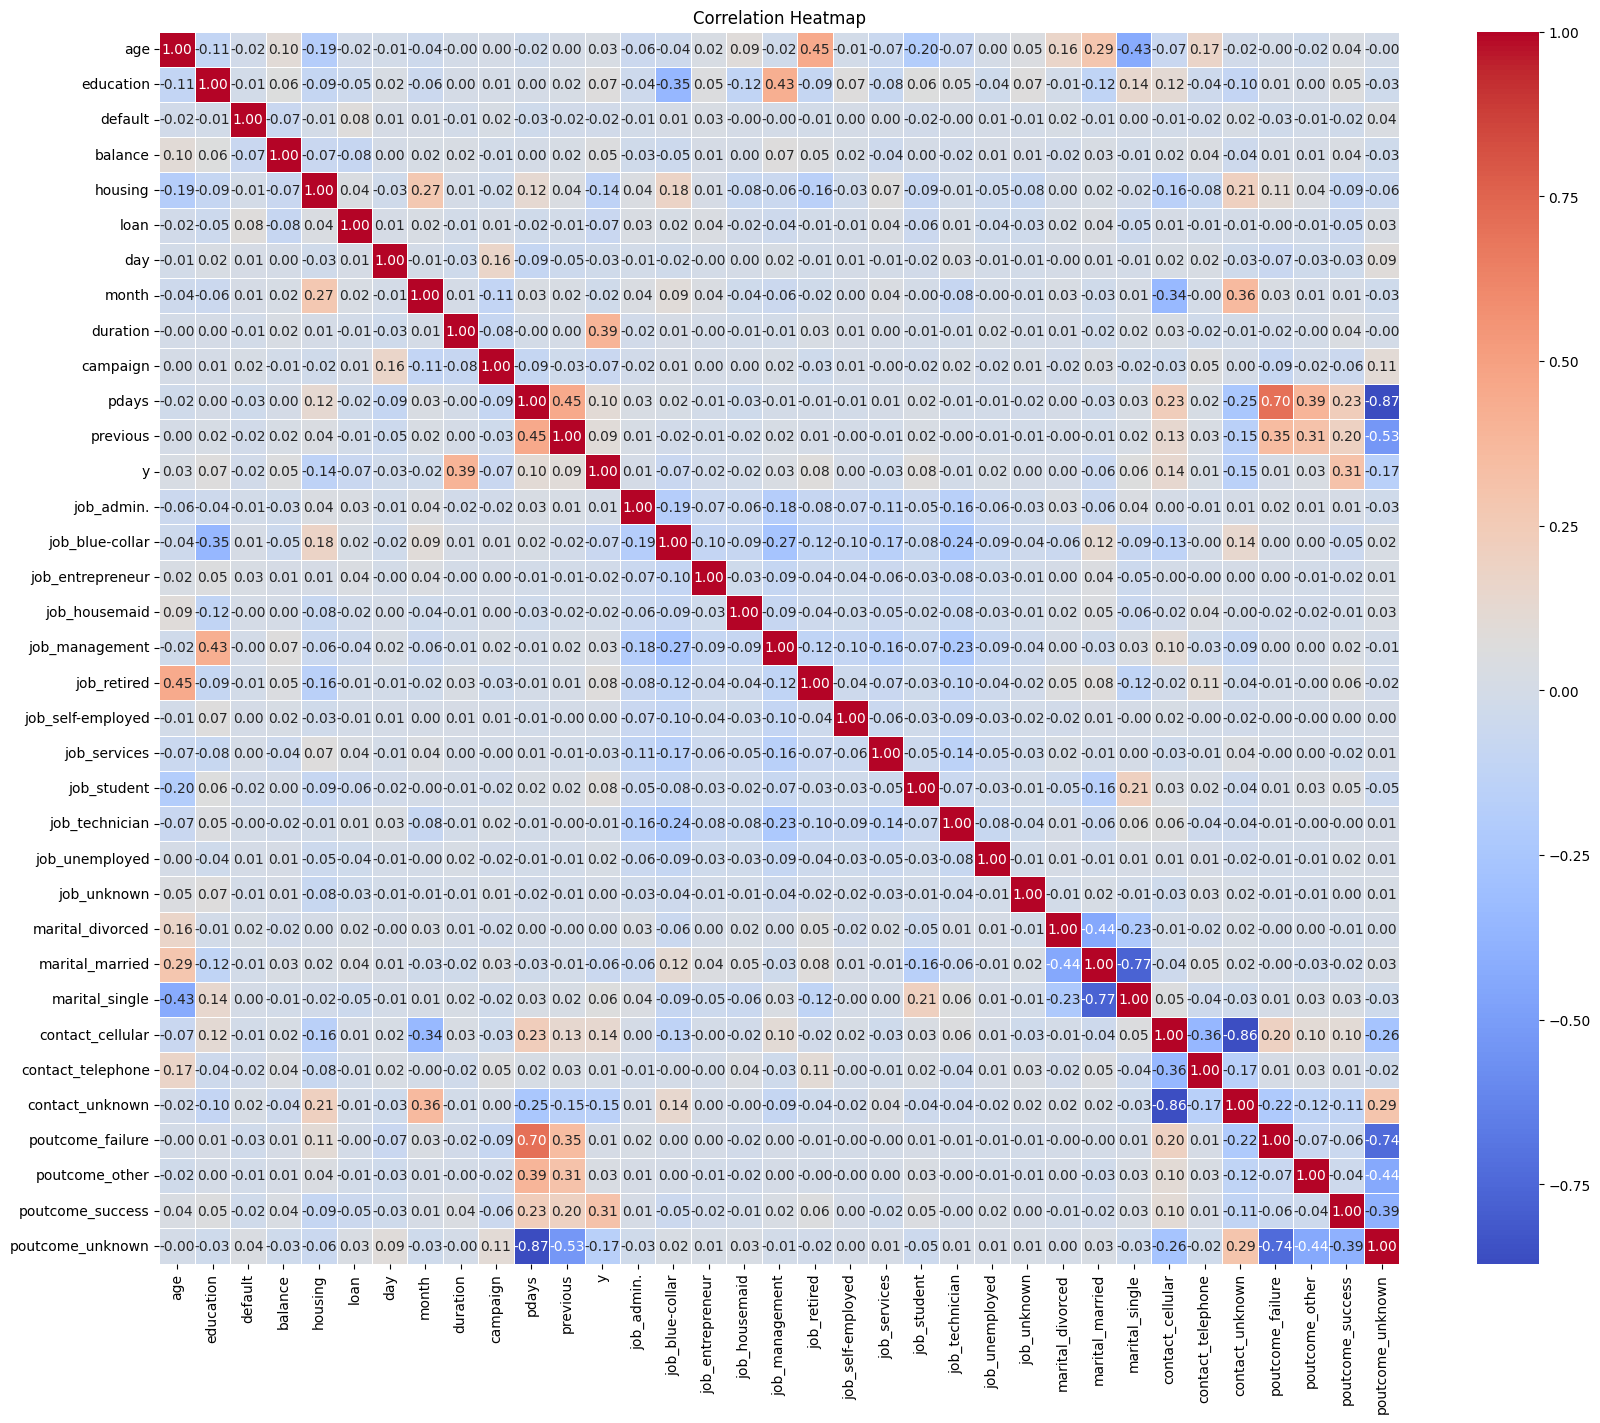

In [24]:
# plot Correlation Heatmap

# Compute correlation matrix
corr_matrix = banking_marketing_train_encoded.corr()

# Plot heatmap
plt.figure(figsize=(20,16))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()


Observations:

Association with y:
 For correlation >= 0.1: duration, pdays, contact_cellular, poutcome_success, poutcome_other; for correlation<= -0.1: housing, contact_unknown, poutcome_unknown; for correlation =0: job = self-employed

Association with poutcome_success/poutcome_failure:
 For correlation >= 0.1: housing, pdays, previous, y, contact_cellular; for correlation <= 0.1: contact_unknown

Other association (correlation >= 0.1): pdays & previous, pdays & contact_cellular/unknown; previous & contact_cellular/unknown

## poutcome & previous

For previous campaigns, is there a relationship between number of tries and success rate?

<ipython-input-25-496fa4b7e589>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='poutcome', y='previous', data=banking_marketing_train, palette="Set2")


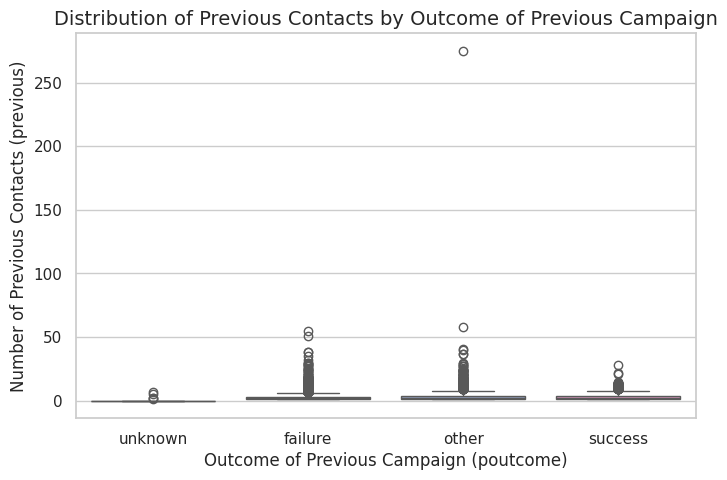

In [25]:
# Set the plot style
sns.set(style="whitegrid")

# Create a boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='poutcome', y='previous', data=banking_marketing_train, palette="Set2")

# Add title and labels
plt.title("Distribution of Previous Contacts by Outcome of Previous Campaign", fontsize=14)
plt.xlabel("Outcome of Previous Campaign (poutcome)")
plt.ylabel("Number of Previous Contacts (previous)")

# Show the plot
plt.show()

Observation: No relationship between poutcome & previous.

## pdays & y

In [26]:
print('-1 \n')
print(banking_marketing_train_encoded[banking_marketing_train_encoded['pdays']==-1]['y'].value_counts())
print('182 \n')
print(banking_marketing_train_encoded[banking_marketing_train_encoded['pdays']==182]['y'].value_counts())
print('92 \n')
print(banking_marketing_train_encoded[banking_marketing_train_encoded['pdays']==92]['y'].value_counts())
print('91 \n')
print(banking_marketing_train_encoded[banking_marketing_train_encoded['pdays']==91]['y'].value_counts())
print('183 \n')
print(banking_marketing_train_encoded[banking_marketing_train_encoded['pdays']==183]['y'].value_counts())

-1 

y
0    33570
1     3384
Name: count, dtype: int64
182 

y
0    87
1    80
Name: count, dtype: int64
92 

y
1    96
0    51
Name: count, dtype: int64
91 

y
1    75
0    51
Name: count, dtype: int64
183 

y
1    64
0    62
Name: count, dtype: int64


y
0    6352
1    1905
Name: count, dtype: int64


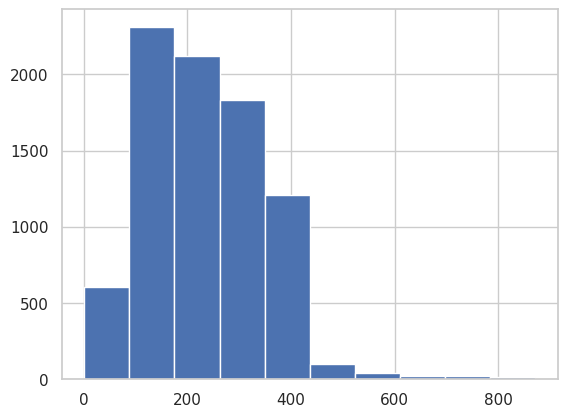

In [27]:
filtered_train = banking_marketing_train_encoded[banking_marketing_train_encoded['pdays']!=-1]
print(filtered_train['y'].value_counts())
# if not previously contacted, much higher probability of failure

filtered_train['pdays'].hist()
plt.show()


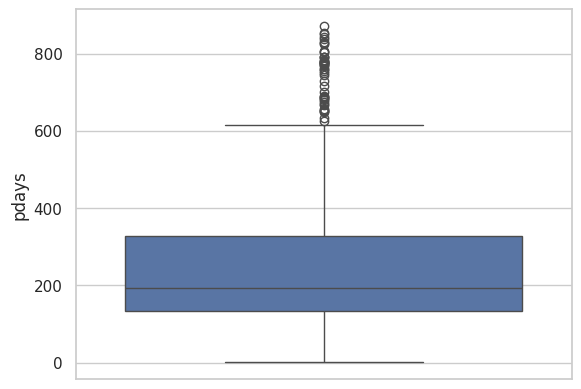

In [28]:
sns.boxplot(filtered_train['pdays'])
plt.show()

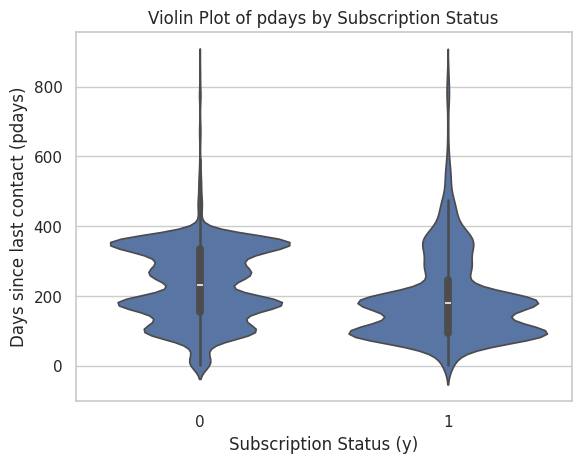

In [29]:
# Create a violin plot for pdays and y
sns.violinplot(x='y', y='pdays', data=filtered_train)
plt.title('Violin Plot of pdays by Subscription Status')
plt.xlabel('Subscription Status (y)')
plt.ylabel('Days since last contact (pdays)')
plt.show()


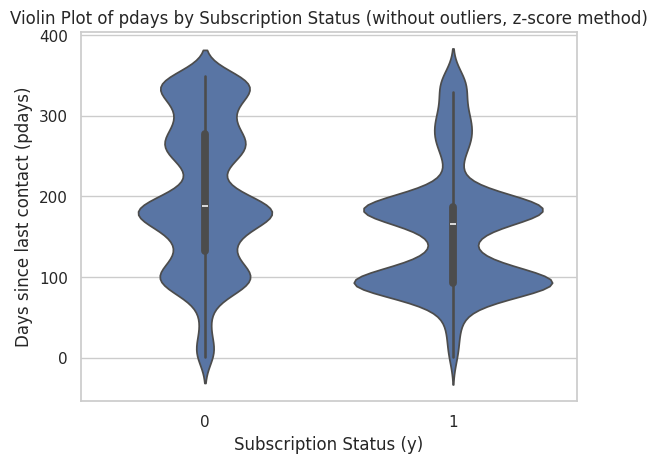

In [30]:
from scipy.stats import zscore

# Filter out rows where the z-score is greater than 3 or less than -3 (common threshold for outliers)
banking_marketing_train_no_outliers_zscore = filtered_train[filtered_train['pdays']<350]

# Plot the violin plot for 'pdays' without outliers using z-score
sns.violinplot(x='y', y='pdays', data=banking_marketing_train_no_outliers_zscore)
plt.title('Violin Plot of pdays by Subscription Status (without outliers, z-score method)')
plt.xlabel('Subscription Status (y)')
plt.ylabel('Days since last contact (pdays)')
plt.show()


Observation: smaller pdays -> higher succes rate.


## duration & y

In [31]:
banking_marketing_train_encoded['duration'].value_counts()

,count
duration,
124,188
90,184
89,177
104,175
114,175
...,...
1286,1
1380,1
1723,1


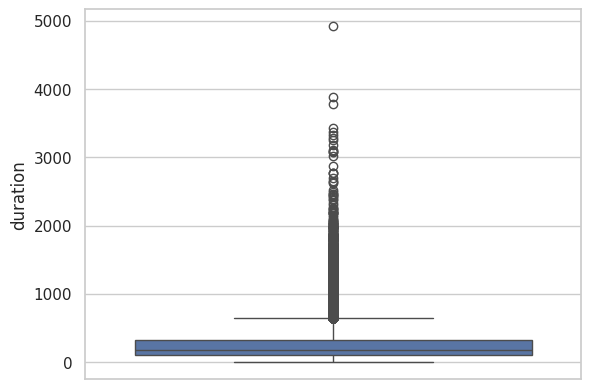

In [32]:
sns.boxplot(banking_marketing_train_encoded['duration'])
plt.show()

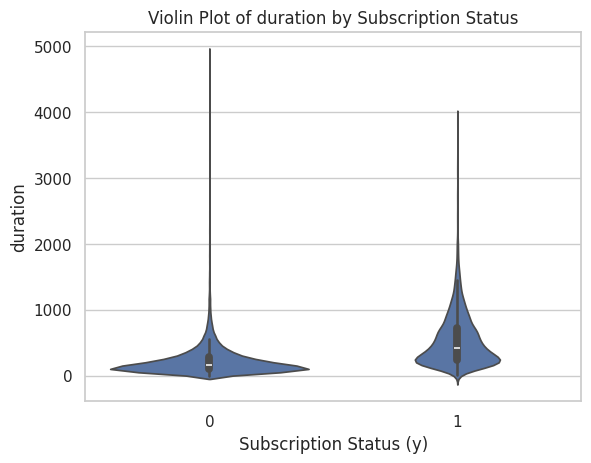

In [33]:
# Create a violin plot for duration and y
sns.violinplot(x='y', y='duration', data=banking_marketing_train_encoded)
plt.title('Violin Plot of duration by Subscription Status')
plt.xlabel('Subscription Status (y)')
plt.ylabel('duration')
plt.show()


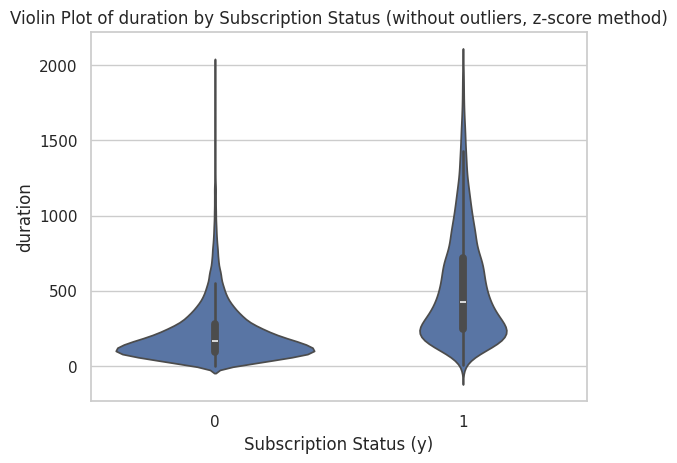

In [34]:

# Filter out rows where the z-score is greater than 3 or less than -3 (common threshold for outliers)
banking_marketing_train_no_outliers_zscore = banking_marketing_train_encoded[banking_marketing_train_encoded['duration']<2000]

# Plot the violin plot for 'pdays' without outliers using z-score
sns.violinplot(x='y', y='duration', data=banking_marketing_train_no_outliers_zscore)
plt.title('Violin Plot of duration by Subscription Status (without outliers, z-score method)')
plt.xlabel('Subscription Status (y)')
plt.ylabel('duration')
plt.show()


Observation: smaller duration -> low success rate.

## previous & y

In [35]:
banking_marketing_train_encoded['previous'].value_counts()

,count
previous,
0,36954
1,2772
2,2106
3,1142
4,714
5,459
6,277
7,205
8,129


In [36]:
print(banking_marketing_train_encoded[banking_marketing_train_encoded['previous']==0]['y'].value_counts())
print(banking_marketing_train_encoded[banking_marketing_train_encoded['previous']==1]['y'].value_counts())
print(banking_marketing_train_encoded[banking_marketing_train_encoded['previous']==2]['y'].value_counts())
print(banking_marketing_train_encoded[banking_marketing_train_encoded['previous']==3]['y'].value_counts())

y
0    33570
1     3384
Name: count, dtype: int64
y
0    2189
1     583
Name: count, dtype: int64
y
0    1650
1     456
Name: count, dtype: int64
y
0    848
1    294
Name: count, dtype: int64


In [37]:
filtered_train = banking_marketing_train_encoded[banking_marketing_train_encoded['previous']!=0]
print(filtered_train['y'].value_counts())
# if not previously contacted, much higher probability of failure?


y
0    6352
1    1905
Name: count, dtype: int64


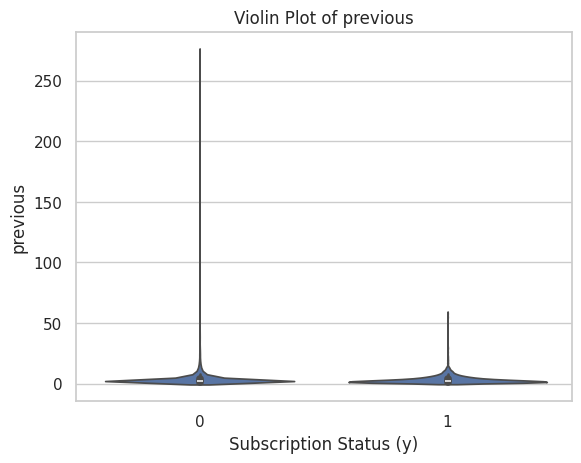

In [38]:
# Create a violin plot for duration and y
sns.violinplot(x='y', y='previous', data=filtered_train)
plt.title('Violin Plot of previous')
plt.xlabel('Subscription Status (y)')
plt.ylabel('previous')
plt.show()


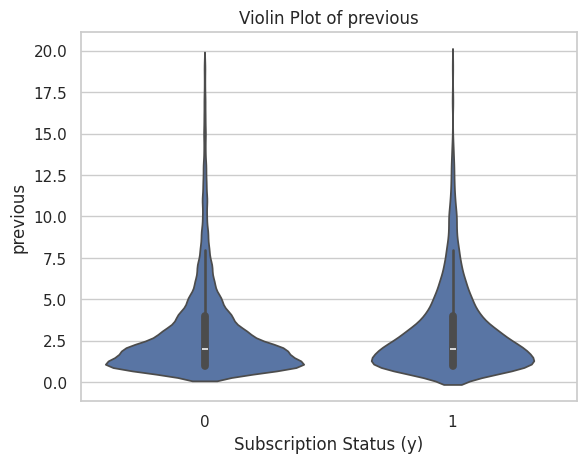

In [39]:
from scipy.stats import zscore

# Filter out rows where the z-score is greater than 3 or less than -3 (common threshold for outliers)
banking_marketing_train_no_outliers_zscore = filtered_train[filtered_train['previous']<20]

# Plot the violin plot for 'pdays' without outliers using z-score
sns.violinplot(x='y', y='previous', data=banking_marketing_train_no_outliers_zscore)
plt.title('Violin Plot of previous')
plt.xlabel('Subscription Status (y)')
plt.ylabel('previous')
plt.show()


In [40]:
# conduct a Mann-Whitney U test to further validate the difference
# If the p-value < 0.05, it indicates that the difference in previous between the two groups is statistically significant.
# If the p-value ≥ 0.05, the difference is not considered significant.
from scipy.stats import mannwhitneyu

group0 = banking_marketing_train_encoded[banking_marketing_train_encoded['y'] == 0]['previous']
group1 = banking_marketing_train_encoded[banking_marketing_train_encoded['y'] == 1]['previous']

stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
print("U-statistic:", stat)
print("p-value:", p)

# p-value ≈ 3.49e-283, confirming a statistically significant difference between the groups, even though the visual difference appears small.


U-statistic: 83972625.0
p-value: 3.491824260414992e-283


Observation: Very weak relationship. The overall distribution of previous contacts is similar between subscribed and non-subscribed clients, those who subscribed tend to have slightly higher previous contact counts, suggesting a weak but statistically significant positive association between repeated contact and subscription.

## y & housing

In [41]:
# housing and y
banking_marketing_train_encoded['housing'].value_counts()

,count
housing,
1,25130
0,20081


In [42]:
# Assuming 'loan' and 'y' are the two binary columns in the DataFrame
contingency_table = pd.crosstab(banking_marketing_train_encoded['housing'], banking_marketing_train_encoded['y'])

# Display the contingency table
print(contingency_table)


y            0     1
housing             
0        16727  3354
1        23195  1935


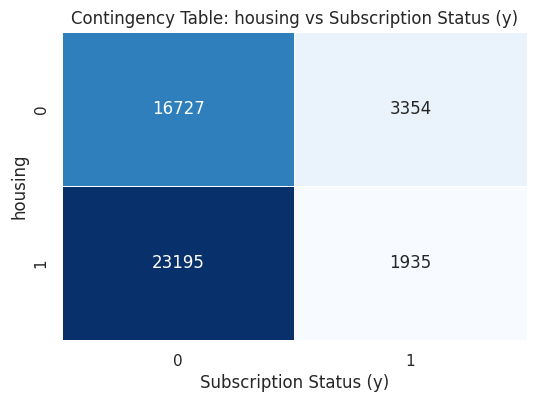

In [43]:
# Plotting the heatmap for the contingency table
plt.figure(figsize=(6, 4))
sns.heatmap(contingency_table, annot=True, fmt="d", cmap="Blues", cbar=False, linewidths=0.5)
plt.title('Contingency Table: housing vs Subscription Status (y)')
plt.xlabel('Subscription Status (y)')
plt.ylabel('housing')
plt.show()


Observation: has housing loan -> low success rate.

## y & poutcome

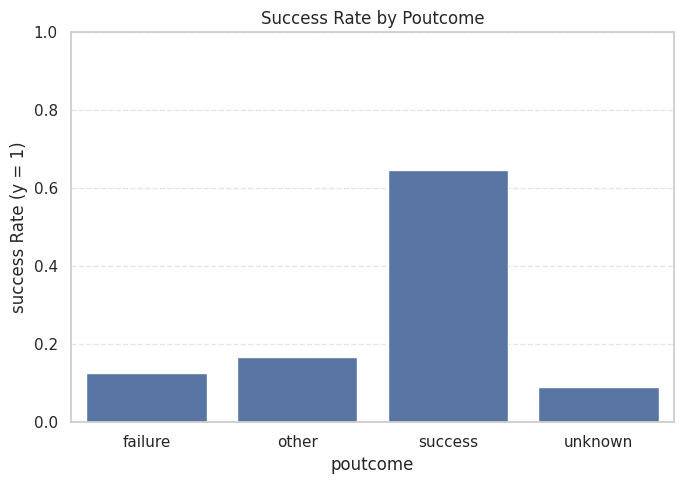

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt

poutcome_columns = [col for col in banking_marketing_train_encoded.columns if col.startswith('poutcome_')]

# restore 'poutcome' column
banking_marketing_train_encoded['poutcome'] = banking_marketing_train_encoded[poutcome_columns].idxmax(axis=1)
banking_marketing_train_encoded['poutcome'] = banking_marketing_train_encoded['poutcome'].str.replace('poutcome_', '')
banking_marketing_test_encoded['poutcome'] = banking_marketing_train_encoded[poutcome_columns].idxmax(axis=1)
banking_marketing_test_encoded['poutcome'] = banking_marketing_train_encoded['poutcome'].str.replace('poutcome_', '')

# bar chart: success rate for different poutcome
poutcome_conversion = banking_marketing_train_encoded.groupby('poutcome')['y'].mean().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=poutcome_conversion, x='poutcome', y='y')
plt.title('Success Rate by Poutcome')
plt.xlabel('poutcome')
plt.ylabel('success Rate (y = 1)')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


Observation: poutcome = success -> higher success rate (y=1).

## y & campaign

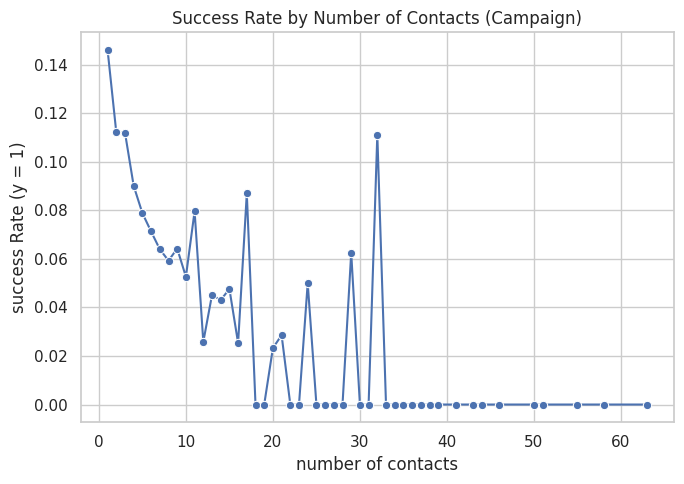

In [45]:
# average success rate(y=1) for diffrent number of contacts performed during this campaign
campaign_conversion = banking_marketing_train_encoded.groupby('campaign')['y'].mean().reset_index()

plt.figure(figsize=(7, 5))
sns.lineplot(data=campaign_conversion, x='campaign', y='y', marker='o')
plt.title('Success Rate by Number of Contacts (Campaign)')
plt.xlabel('number of contacts')
plt.ylabel('success Rate (y = 1)')
plt.grid(True)
plt.tight_layout()
plt.show()


Observation: There is a negative relationship between the number of contact attempts (campaign) and success rate (y=1).
higher number of contacts -> lower success rate.

This suggests that contacting clients too many times may lead to diminishing returns or even campaign fatigue.

## y & campaign (Conversion Rate groupby contact method)

<ipython-input-46-6d3435fc6c39>:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  conversion_by_contact = banking_marketing_train_encoded.groupby('contact').apply(


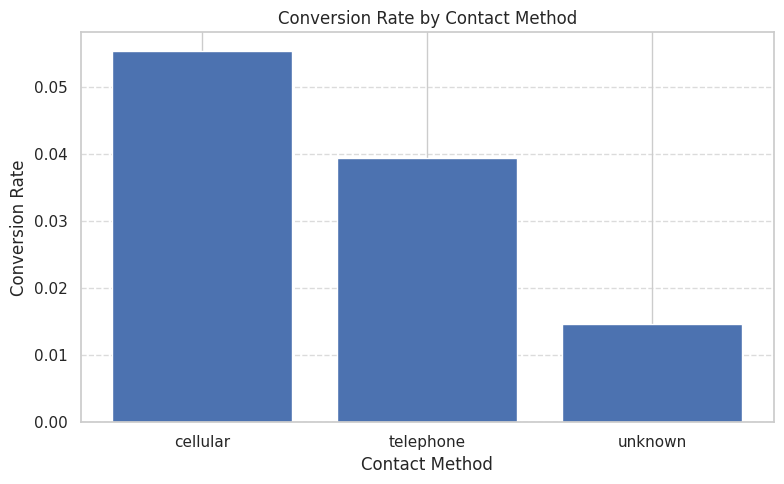

     contact  conversion_rate
0   cellular         0.055458
1  telephone         0.039462
2    unknown         0.014603


In [46]:
# Conversion Rate = (Number of Conversions ÷ Total Interactions) × 100%
# Here, the conversion rate can be calculated by dividing the number of successful conversions(column 'y') by the total number of contact attempts(column 'campaign').
# Restore the nominal columns
for col in nominal_columns:
    banking_marketing_train_encoded[col] = banking_marketing_train[col]
    banking_marketing_test_encoded[col] = banking_marketing_test[col]

# conversion rate groupby 'contact'
conversion_by_contact = banking_marketing_train_encoded.groupby('contact').apply(
    lambda d: d['y'].sum() / d['campaign'].sum() if d['campaign'].sum() != 0 else float('nan')
).reset_index(name='conversion_rate')

# visualize
plt.figure(figsize=(8, 5))
plt.bar(conversion_by_contact['contact'], conversion_by_contact['conversion_rate'])
plt.title('Conversion Rate by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('Conversion Rate')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print(conversion_by_contact)

Observation: The conversion rate of cellular > telephone > unknown.

Contact communication type can affect the success rate (y=1) significantly.

# Feature Engineering

In simple terms, ROI = revenue/cost

However, the dataset provides limited information directly related to these components.

For instance, cost-related variables include duration, contact communication type, and the number of contacts, while revenue-related indicators are limited to poutcome and y.

This information alone is insufficient to accurately compute or infer revenue and cost. Therefore, we had to supplement the dataset by sourcing external information or generating reasonable assumptions to fill these gaps.









## 1. deposit_amount, deposit_term, interest_rate

Generate features to estimate the fundamental revenue of this campaign.

In [47]:
banking_marketing_train.head()
banking_marketing_train['y']

,y
0,0
1,0
2,0
3,0
4,0
...,...
45206,1
45207,1
45208,1
45209,0


In [48]:
# Interest rates from 2008/7 to 2010/12, estimated from ECB, with the help of GenAI ChatGPT
rate_table=[
    {"time":"2008/7","current": 0.75,"three_months": 3.20,"six_months": 3.60,"one_year": 3.85,"two_year": 4.05},
    {"time":"2008/12","current": 0.40,"three_months": 2.10,"six_months": 2.50,"one_year": 2.75,"two_year": 3.00},
    {"time":"2009/5","current": 0.30,"three_months": 1.20,"six_months": 1.50,"one_year": 1.70,"two_year": 2.00},
    {"time":"2009/12","current": 0.25,"three_months": 1.00,"six_months": 1.25,"one_year": 1.40,"two_year": 1.70},
    {"time":"2010/6","current": 0.20,"three_months": 0.90,"six_months": 1.10,"one_year": 1.25,"two_year": 1.55},
    {"time":"2010/12","current": 0.20,"three_months": 0.85,"six_months": 1.00,"one_year": 1.20,"two_year": 1.50}
]

# Deposit terms
deposit_products=["current","three_months","six_months","one_year","two_year"]

# Generate synthetic deposit features (amount, term, interest rate) for customers who subscribed (y=1); return NaN otherwise
def generate_deposit_features(y_value):
    deposit_amount=np.random.choice(np.arange(1000,500000+1,100)) # Deposit range
    rate_row=np.random.choice(rate_table)
    deposit_product=np.random.choice(deposit_products)
    interest_rate=rate_row[deposit_product]
    deposit_term=deposit_product
    return pd.Series([deposit_amount,deposit_term,interest_rate])

# deposit_amount, deposit_term, interest_rate
# assume: actual deposit features (when y=1), campaign recommended features (when y=0)
banking_marketing_train_encoded[["deposit_amount", "term", "interest_rate"]] = banking_marketing_train_encoded['y'].apply(generate_deposit_features)
banking_marketing_test_encoded[["deposit_amount", "term", "interest_rate"]] = banking_marketing_test_encoded['y'].apply(generate_deposit_features)

# Use oversample to solve the problem of imbalanced data
train_yes=banking_marketing_train_encoded[banking_marketing_train_encoded['y'] == 1]
train_oversampled=pd.concat([banking_marketing_train_encoded]+[train_yes]*6,ignore_index=True)
result=pd.concat([train_oversampled, banking_marketing_test_encoded],axis=0)

banking_marketing_train_encoded.head()
train_sorted = banking_marketing_train_encoded.sort_values(by='deposit_amount', ascending=False)
print(train_sorted[['y', 'poutcome', 'deposit_amount', 'interest_rate']].head())

# Deposit term encoding
deposit_products = ["current", "three_months", "six_months", "one_year", "two_year"]
ordinal_encoder = OrdinalEncoder(categories=[deposit_products])

banking_marketing_train_encoded['term'] = ordinal_encoder.fit_transform(banking_marketing_train_encoded[['term']]).flatten()
banking_marketing_test_encoded['term'] = ordinal_encoder.transform(banking_marketing_test_encoded[['term']]).flatten()



       y poutcome  deposit_amount  interest_rate
6322   0  unknown          500000           0.20
43990  1  success          500000           1.25
26986  0  failure          500000           0.40
110    0  unknown          500000           3.85
40506  1  failure          500000           1.50


## 2. cost
The overall cost is associated with several factors, including the number of contact attempts (campaign), the duration of each call (duration), and the communication channel (contact).

Based on industry estimates from Magellan Solutions https://www.magellan-solutions.com/blog/cost-of-telemarketing/, we approximate the cost using the following formula:

Cost = (duration × campaign) / 3600 × 38 USD (duration is measured in seconds, and we assume a telemarketing rate of USD 38 per hour).

In [49]:
banking_marketing_train.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [50]:
banking_marketing_train_encoded.columns

Index(['age', 'education', 'default', 'balance', 'housing', 'loan', 'day',
       'month', 'duration', 'campaign', 'pdays', 'previous', 'y', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'poutcome_unknown', 'poutcome', 'job', 'marital', 'contact',
       'deposit_amount', 'term', 'interest_rate'],
      dtype='object')

In [51]:
# Count the frequency of each unique value in the 'contact' column
contact_counts = banking_marketing_train['contact'].value_counts()

# Display the result
print(contact_counts)

contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64


In [52]:
# Estimate cost
banking_marketing_train_encoded['cost'] = banking_marketing_train_encoded['duration'] * banking_marketing_train_encoded['campaign'] / 3600 * 38
banking_marketing_test_encoded['cost'] = banking_marketing_test_encoded['duration'] * banking_marketing_test_encoded['campaign'] / 3600 * 38

banking_marketing_test_encoded.columns

Index(['age', 'education', 'default', 'balance', 'housing', 'loan', 'day',
       'month', 'duration', 'campaign', 'pdays', 'previous', 'y', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'poutcome_unknown', 'poutcome', 'job', 'marital', 'contact',
       'deposit_amount', 'term', 'interest_rate', 'cost'],
      dtype='object')

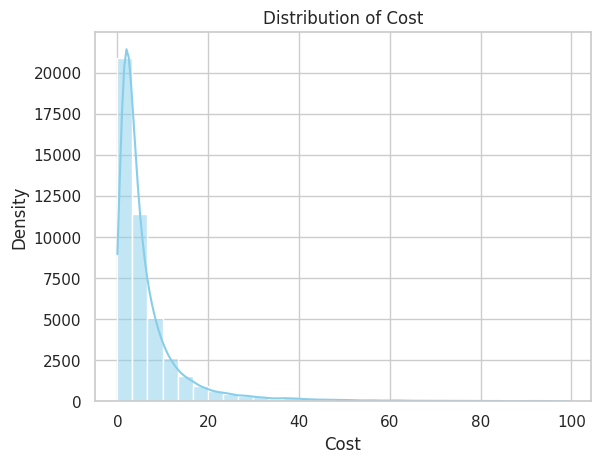

In [53]:
# Drop missing values from 'cost' column (if any) to ensure clean plotting
clean_cost_data = banking_marketing_train_encoded[banking_marketing_train_encoded['cost']<100]['cost'].dropna()

# Plot the distribution of the 'cost' column
sns.histplot(clean_cost_data, kde=True, color='skyblue', bins=30)

# Set plot labels and title
plt.title('Distribution of Cost')
plt.xlabel('Cost')
plt.ylabel('Density')

# Show the plot
plt.show()

## 3. Customer Lifetime Value (CLV)

CLV is essentially a more advanced and forward-looking way of calculating revenue, as it estimates the total value a customer brings over their entire relationship with the business.


In [54]:
banking_marketing_train_encoded.head()

,age,education,default,balance,housing,loan,day,month,duration,campaign,...,poutcome_success,poutcome_unknown,poutcome,job,marital,contact,deposit_amount,term,interest_rate,cost
0,58,2,0,2143,1,0,5,8,261,1,...,False,True,unknown,management,married,unknown,420500,2.0,2.50,2.755000
1,44,1,0,29,1,0,5,8,151,1,...,False,True,unknown,technician,single,unknown,466700,1.0,0.90,1.593889
2,33,1,0,2,1,1,5,8,76,1,...,False,True,unknown,entrepreneur,married,unknown,320000,2.0,2.50,0.802222
3,47,3,0,1506,1,0,5,8,92,1,...,False,True,unknown,blue-collar,married,unknown,340200,2.0,1.50,0.971111
4,33,3,0,1,0,0,5,8,198,1,...,False,True,unknown,unknown,single,unknown,60500,3.0,2.75,2.090000


In [55]:
# CLV = Customer Value * Customer Lifespan = (Purchase Frequency * Revenue per Purchase) * Customer Lifespan

## purchase frequency (across two campaigns by summing successful outcomes from 'poutcome' and 'y')
def calc_purchase_freq(row):
    freq = 0
    if row['poutcome'] == 'success':
        freq += 1
    if row['y'] == 1:
        freq += 1
    return freq

banking_marketing_train_encoded['purchase_frequency'] = banking_marketing_train_encoded.apply(calc_purchase_freq, axis=1)
banking_marketing_test_encoded['purchase_frequency'] = banking_marketing_test_encoded.apply(calc_purchase_freq, axis=1)



In [56]:
## Revenue per Purchase = Revenue / Total Number of Purchases
## In this case, the current campaign is assumed to result in one purchase(refer to deposit_amount), so we only need to calculate the revenue.
## Revenue = deposit_amount × interest_rate, use actual deposit features (when y=1)

banking_marketing_train_encoded['revenue'] = banking_marketing_train_encoded.apply(
    lambda row: row['deposit_amount'] * row['interest_rate'] if row['y'] == 1 else 0,
    axis=1
)
banking_marketing_test_encoded['revenue'] = banking_marketing_test_encoded.apply(
    lambda row: row['deposit_amount'] * row['interest_rate'] if row['y'] == 1 else 0,
    axis=1
)

In [57]:
## Estimate Customer Lifespan (in days)
## a projected value that measures how long the customer will continue to maintain a relationship with the company in the future

## Considering that an individual's financial engagement can extend from retirement to the end of life,
## the global average retirement age is 64 (estimated from World Population Review data);
## the global average death age is 73.5 (from worldometer data);
## thus, customer lifespan = [(64 + 73.5)/2 = 69 (to the nearest whole number)] - customer's current age

banking_marketing_train_encoded['customer_lifespan'] = (69 - banking_marketing_train_encoded['age']) * 365
banking_marketing_test_encoded['customer_lifespan'] = (69 - banking_marketing_train_encoded['age']) * 365

In [58]:
## Calculate CLV
banking_marketing_train_encoded['CLV'] = banking_marketing_train_encoded['purchase_frequency'] * banking_marketing_train_encoded['customer_lifespan'] * banking_marketing_train_encoded['revenue']
banking_marketing_test_encoded['CLV'] = (banking_marketing_test_encoded['purchase_frequency'] * banking_marketing_test_encoded['customer_lifespan'] * banking_marketing_test_encoded['revenue'])

train_sorted = banking_marketing_train_encoded.sort_values(by='CLV', ascending=False)
print(train_sorted[['y', 'poutcome', 'deposit_amount', 'interest_rate', 'purchase_frequency', 'customer_lifespan', 'revenue', 'CLV']].head())


       y poutcome  deposit_amount  interest_rate  purchase_frequency  \
45005  1  success          482700           3.85                   2   
43498  1  success          495900           3.00                   2   
43868  1  success          436900           3.85                   2   
42846  1  success          494600           3.60                   2   
43807  1  success          316000           4.05                   2   

       customer_lifespan    revenue           CLV  
45005              15695  1858395.0  5.833502e+10  
43498              17155  1487700.0  5.104299e+10  
43868              14235  1682065.0  4.788839e+10  
42846              13140  1780560.0  4.679312e+10  
43807              16790  1279800.0  4.297568e+10  


## 4. Customer Aquisition Cost (CAC)

CAC should be computed at the group level (e.g., by contact type) to reflect the average cost per acquired customer, and assign it to each row if needed.

should not be calculated row by row using individual y values (0/1), as it leads to statistical bias and division by zero.  

In [59]:
# CAC = total costs / number of new customers gained within a specific period
# Use cost, poutcome (success or failure in the previous campaign), y (whether they subscribed in the current campaign)

## new customer: someone whose previous campaign outcome was unsuccessful but who subscribed in the current campaign
def is_new_customer(row):
    return row['poutcome'] != 'success' and row['y'] == 1

banking_marketing_train_encoded['new_customer'] = banking_marketing_train_encoded.apply(is_new_customer, axis=1)
banking_marketing_test_encoded['new_customer'] = banking_marketing_test_encoded.apply(is_new_customer, axis=1)


In [60]:
## compute CAC at the group level (by contact type)
cac_by_contact_train = (
    banking_marketing_train_encoded
    .groupby('contact')
    .apply(lambda d: d['cost'].sum() / d['new_customer'].sum() if d['new_customer'].sum() > 0 else float('nan'))
    .reset_index(name='CAC')
)

cac_by_contact_test = (
    banking_marketing_test_encoded
    .groupby('contact')
    .apply(lambda d: d['cost'].sum() / d['new_customer'].sum() if d['new_customer'].sum() > 0 else float('nan'))
    .reset_index(name='CAC')
)

## assign CAC to each row
banking_marketing_train_encoded = banking_marketing_train_encoded.merge(cac_by_contact_train, on='contact', how='left')
banking_marketing_test_encoded = banking_marketing_test_encoded.merge(cac_by_contact_test, on='contact', how='left')


<ipython-input-60-c62f719e0898>:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d['cost'].sum() / d['new_customer'].sum() if d['new_customer'].sum() > 0 else float('nan'))
<ipython-input-60-c62f719e0898>:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: d['cost'].sum() / d['new_customer'].sum() if d['new_customer'].sum() > 0 else float('nan'))


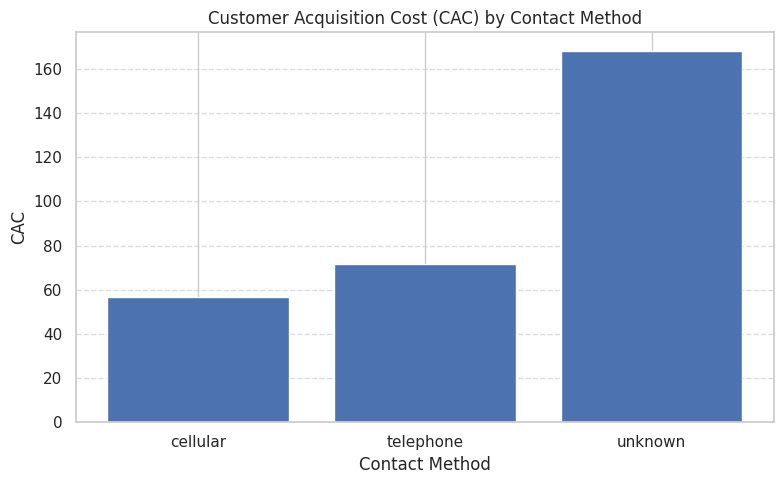

,age,education,default,balance,housing,loan,day,month,duration,campaign,...,deposit_amount,term,interest_rate,cost,purchase_frequency,revenue,customer_lifespan,CLV,new_customer,CAC
0,58,2,0,2143,1,0,5,8,261,1,...,420500,2.0,2.50,2.755000,0,0.0,4015,0.0,False,168.21091
1,44,1,0,29,1,0,5,8,151,1,...,466700,1.0,0.90,1.593889,0,0.0,9125,0.0,False,168.21091
2,33,1,0,2,1,1,5,8,76,1,...,320000,2.0,2.50,0.802222,0,0.0,13140,0.0,False,168.21091
3,47,3,0,1506,1,0,5,8,92,1,...,340200,2.0,1.50,0.971111,0,0.0,8030,0.0,False,168.21091
4,33,3,0,1,0,0,5,8,198,1,...,60500,3.0,2.75,2.090000,0,0.0,13140,0.0,False,168.21091


In [61]:
# visualize
plt.figure(figsize=(8, 5))
plt.bar(cac_by_contact_train['contact'], cac_by_contact_train['CAC'])
plt.title('Customer Acquisition Cost (CAC) by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('CAC')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

banking_marketing_train_encoded.head()


Observation: CAC of unknown > telephone > cellular

## 5. Conversion Rate


In [62]:
# Conversion Rate for each row (success rate per contact attempt)

banking_marketing_train_encoded['conversion_rate'] = banking_marketing_train_encoded['y'] / banking_marketing_train_encoded['campaign']
banking_marketing_test_encoded['conversion_rate'] = banking_marketing_test_encoded['y'] / banking_marketing_test_encoded['campaign']


banking_marketing_train_encoded.head()

,age,education,default,balance,housing,loan,day,month,duration,campaign,...,term,interest_rate,cost,purchase_frequency,revenue,customer_lifespan,CLV,new_customer,CAC,conversion_rate
0,58,2,0,2143,1,0,5,8,261,1,...,2.0,2.50,2.755000,0,0.0,4015,0.0,False,168.21091,0.0
1,44,1,0,29,1,0,5,8,151,1,...,1.0,0.90,1.593889,0,0.0,9125,0.0,False,168.21091,0.0
2,33,1,0,2,1,1,5,8,76,1,...,2.0,2.50,0.802222,0,0.0,13140,0.0,False,168.21091,0.0
3,47,3,0,1506,1,0,5,8,92,1,...,2.0,1.50,0.971111,0,0.0,8030,0.0,False,168.21091,0.0
4,33,3,0,1,0,0,5,8,198,1,...,3.0,2.75,2.090000,0,0.0,13140,0.0,False,168.21091,0.0


## 6. ROI

The CLV/CAC ratio helps measure return on Marketing spend, it is a financial ratio that measures the ROI. (Cube Software https://www.cubesoftware.com/blog/ltv-cac-ratio)

It calculates the value generated for each dollar spent on acquiring a customer


In [63]:
# ROI = CLV/CAC

banking_marketing_train_encoded['ROI'] = banking_marketing_train_encoded['CLV']  / banking_marketing_train_encoded['CAC']
banking_marketing_test_encoded['ROI'] = banking_marketing_test_encoded['CLV']  / banking_marketing_test_encoded['CAC']


       y  campaign       cost  conversion_rate           CLV        CAC  \
45005  1         1   2.047778              1.0  5.833502e+10  56.819262   
43498  1         1   5.583889              1.0  5.104299e+10  56.819262   
43868  1         2   4.306667              0.5  4.788839e+10  56.819262   
42846  1         1   3.747222              1.0  4.679312e+10  56.819262   
43807  1         1  12.434444              1.0  4.297568e+10  56.819262   

                ROI  
45005  1.026677e+09  
43498  8.983395e+08  
43868  8.428196e+08  
42846  8.235432e+08  
43807  7.563577e+08  


In [64]:
banking_marketing_train_encoded.head()

,age,education,default,balance,housing,loan,day,month,duration,campaign,...,interest_rate,cost,purchase_frequency,revenue,customer_lifespan,CLV,new_customer,CAC,conversion_rate,ROI
0,58,2,0,2143,1,0,5,8,261,1,...,2.50,2.755000,0,0.0,4015,0.0,False,168.21091,0.0,0.0
1,44,1,0,29,1,0,5,8,151,1,...,0.90,1.593889,0,0.0,9125,0.0,False,168.21091,0.0,0.0
2,33,1,0,2,1,1,5,8,76,1,...,2.50,0.802222,0,0.0,13140,0.0,False,168.21091,0.0,0.0
3,47,3,0,1506,1,0,5,8,92,1,...,1.50,0.971111,0,0.0,8030,0.0,False,168.21091,0.0,0.0
4,33,3,0,1,0,0,5,8,198,1,...,2.75,2.090000,0,0.0,13140,0.0,False,168.21091,0.0,0.0


In [65]:
banking_marketing_train_encoded.columns

Index(['age', 'education', 'default', 'balance', 'housing', 'loan', 'day',
       'month', 'duration', 'campaign', 'pdays', 'previous', 'y', 'job_admin.',
       'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_divorced', 'marital_married', 'marital_single',
       'contact_cellular', 'contact_telephone', 'contact_unknown',
       'poutcome_failure', 'poutcome_other', 'poutcome_success',
       'poutcome_unknown', 'poutcome', 'job', 'marital', 'contact',
       'deposit_amount', 'term', 'interest_rate', 'cost', 'purchase_frequency',
       'revenue', 'customer_lifespan', 'CLV', 'new_customer', 'CAC',
       'conversion_rate', 'ROI'],
      dtype='object')

# Data Normalization

In [66]:
# Numeric columns to standardize
numeric_columns = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous', 'deposit_amount']
numeric_columns = [col for col in numeric_columns if col in banking_marketing_train.columns]

scaler = StandardScaler()
for col in numeric_columns:
    banking_marketing_train_encoded[col] = scaler.fit_transform(banking_marketing_train[col].values.reshape(-1, 1)).flatten()
    banking_marketing_test_encoded[col] = scaler.transform(banking_marketing_test[col].values.reshape(-1, 1)).flatten()

numeric_columns = ['deposit_amount']
numeric_columns = [col for col in numeric_columns if col in banking_marketing_train.columns]

banking_marketing_train_encoded['deposit_amount'] = scaler.fit_transform(banking_marketing_train_encoded['deposit_amount'].values.reshape(-1, 1)).flatten()
banking_marketing_test_encoded['deposit_amount'] = scaler.transform(banking_marketing_test_encoded['deposit_amount'].values.reshape(-1, 1)).flatten()


In [68]:
train_sorted = banking_marketing_train_encoded.sort_values(by='CLV', ascending=False)
print(train_sorted[['y', 'poutcome', 'deposit_amount', 'interest_rate', 'cost', 'purchase_frequency', 'customer_lifespan', 'revenue', 'CAC', 'CLV', 'conversion_rate']].head())


       y poutcome  deposit_amount  interest_rate       cost  \
45005  1  success        1.620869           3.85   2.047778   
43498  1  success        1.713024           3.00   5.583889   
43868  1  success        1.301117           3.85   4.306667   
42846  1  success        1.703948           3.60   3.747222   
43807  1  success        0.457057           4.05  12.434444   

       purchase_frequency  customer_lifespan    revenue        CAC  \
45005                   2              15695  1858395.0  56.819262   
43498                   2              17155  1487700.0  56.819262   
43868                   2              14235  1682065.0  56.819262   
42846                   2              13140  1780560.0  56.819262   
43807                   2              16790  1279800.0  56.819262   

                CLV  conversion_rate  
45005  5.833502e+10              1.0  
43498  5.104299e+10              1.0  
43868  4.788839e+10              0.5  
42846  4.679312e+10              1.0  
43807

In [69]:
banking_marketing_train_encoded.head()

,age,education,default,balance,housing,loan,day,month,duration,campaign,...,interest_rate,cost,purchase_frequency,revenue,customer_lifespan,CLV,new_customer,CAC,conversion_rate,ROI
0,1.606965,2,0,0.256419,1,0,-1.298476,8,0.011016,-0.569351,...,2.50,2.755000,0,0.0,4015,0.0,False,168.21091,0.0,0.0
1,0.288529,1,0,-0.437895,1,0,-1.298476,8,-0.416127,-0.569351,...,0.90,1.593889,0,0.0,9125,0.0,False,168.21091,0.0,0.0
2,-0.747384,1,0,-0.446762,1,1,-1.298476,8,-0.707361,-0.569351,...,2.50,0.802222,0,0.0,13140,0.0,False,168.21091,0.0,0.0
3,0.571051,3,0,0.047205,1,0,-1.298476,8,-0.645231,-0.569351,...,1.50,0.971111,0,0.0,8030,0.0,False,168.21091,0.0,0.0
4,-0.747384,3,0,-0.447091,0,0,-1.298476,8,-0.233620,-0.569351,...,2.75,2.090000,0,0.0,13140,0.0,False,168.21091,0.0,0.0
